In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.layers import Dense, ReLU
from tensorflow.keras.layers import Embedding, BatchNormalization, Concatenate,Input
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Sequential, Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical


In [2]:
# Correctly load the datasets with proper parsing
train_df = pd.read_csv('C:/Users/bchal/OneDrive/Documents/stage pfe master/MindCare-AI/AI/dataEmotion/test.csv')
val_df = pd.read_csv('C:/Users/bchal/OneDrive/Documents/stage pfe master/MindCare-AI/AI/dataEmotion/train.csv')
test_df = pd.read_csv('C:/Users/bchal/OneDrive/Documents/stage pfe master/MindCare-AI/AI/dataEmotion/val.csv')

# Function to split text and emotion
def split_text_emotion(df):
    # Split the text_with_emotion column at the last semicolon
    df[['text', 'emotion']] = df['text_with_emotion'].str.rsplit(';', n=1, expand=True)
    # Drop the original column
    df.drop('text_with_emotion', axis=1, inplace=True)
    return df
# Extract emotion from the text column and create a proper emotion column
# Modified fix_dataframe function
def fix_dataframe(df):
    # Create a temporary copy
    fixed_df = df.copy()
    
    # Extract the emotion from the text_with_emotion field
    fixed_df['text_parts'] = fixed_df['text_with_emotion'].str.split(';')
    fixed_df['fixed_emotion'] = fixed_df['text_parts'].apply(lambda x: x[-1] if len(x) > 1 else None)
    fixed_df['fixed_text'] = fixed_df['text_parts'].apply(lambda x: ';'.join(x[:-1]) if len(x) > 1 else x[0])
    
    # Create new dataframe with correct columns
    result = pd.DataFrame({
        'text': fixed_df['fixed_text'],
        'emotion': fixed_df['fixed_emotion']
    })
    
    return result

# Apply the simpler function to all datasets
#train_data = split_text_emotion(train_data)
#val_data = split_text_emotion(val_data)
#test_data = split_text_emotion(test_data)

In [3]:
# Check the first few rows of the training data
print(train_df.head())

# Check emotion distribution
print(train_df['emotion'].value_counts())

                                                text  emotion
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate from me because i do...  sadness
3  i left with my bouquet of red and yellow tulip...      joy
4    i was feeling a little vain when i did this one  sadness
emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64


In [4]:
# Create output directory if it doesn't exist
output_dir = 'dataEmotion'
os.makedirs(output_dir, exist_ok=True)

# Save the processed datasets
#train_data.to_csv(f'{output_dir}/train.csv', index=False)
#val_data.to_csv(f'{output_dir}/val.csv', index=False)
#test_data.to_csv(f'{output_dir}/test.csv', index=False)

print(f"Datasets saved to {output_dir} folder:")
print(f" - train.csv: {len(train_df)} records")
print(f" - val.csv: {len(val_df)} records")
print(f" - test.csv: {len(test_df)} records")

Datasets saved to dataEmotion folder:
 - train.csv: 2000 records
 - val.csv: 16000 records
 - test.csv: 2000 records


In [5]:
train_df

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


In [6]:
train_df['emotion'].unique()

array(['sadness', 'joy', 'fear', 'anger', 'love', 'surprise'],
      dtype=object)

In [7]:
train_df.emotion.value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

# Count label distributions Train

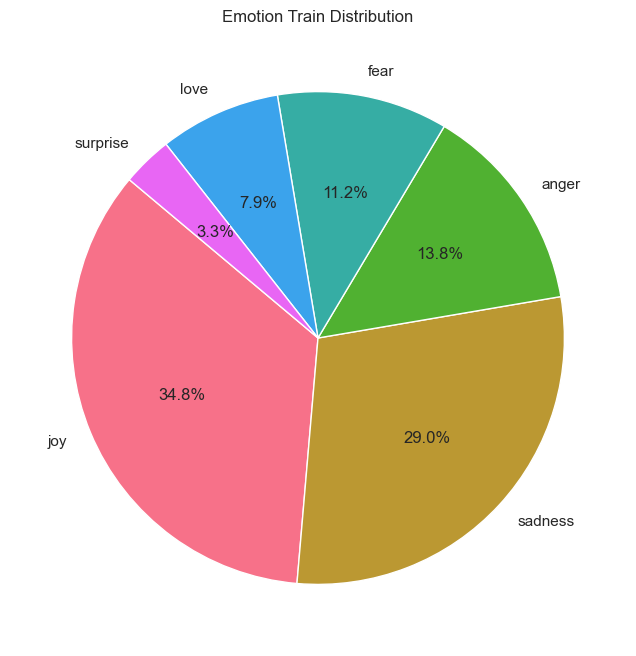

In [8]:

emotion_counts = train_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(emotion_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Train Distribution')
plt.show()

# Count label distributions Validation

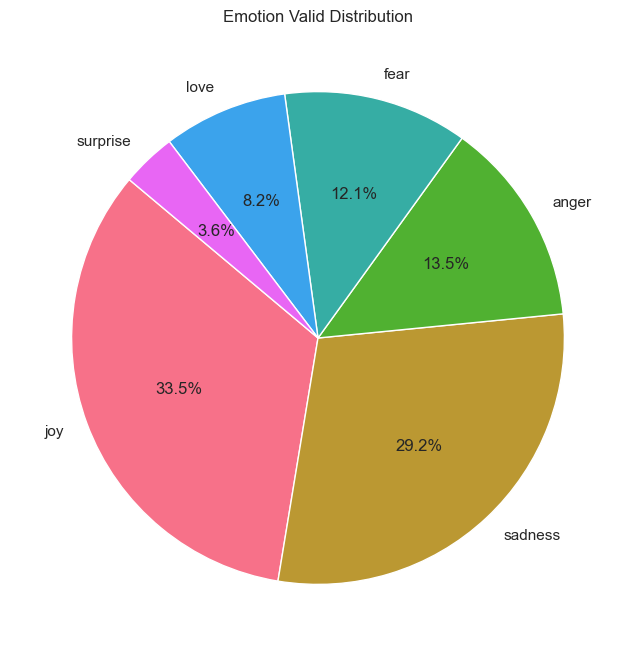

In [9]:
label_counts = val_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Valid Distribution')
plt.show()

# Count label distributions Test

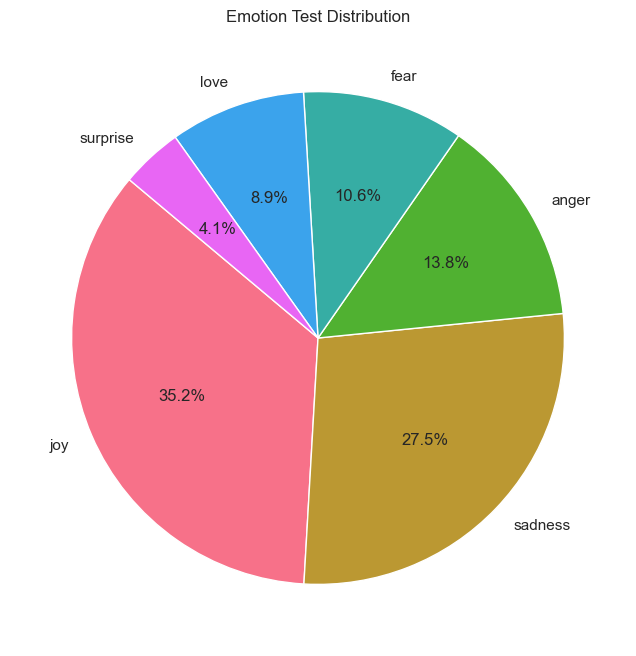

In [10]:
label_counts = test_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Test Distribution')
plt.show()

remove both surprise and love labels since they are the lowest and reduce each label to make the dataset balanced.

In [11]:
train_df = train_df[~train_df['emotion'].str.contains('love')]
train_df = train_df[~train_df['emotion'].str.contains('surprise')]

In [12]:
# Check how many samples are available for each emotion
print("Available samples for each emotion:")
print(train_df['emotion'].value_counts())

Available samples for each emotion:
emotion
joy        695
sadness    581
anger      275
fear       224
Name: count, dtype: int64


In [13]:
# Option 2: Sample with replacement
joy = train_df[train_df['emotion'] == 'joy'].sample(n=2200, random_state=20, replace=True)
sad = train_df[train_df['emotion'] == 'sadness'].sample(n=2200, random_state=20, replace=True)
fear = train_df[train_df['emotion'] == 'fear'].sample(n=1937, random_state=20, replace=True)
anger = train_df[train_df['emotion'] == 'anger'].sample(n=2159, random_state=20, replace=True)

train_df_sampled = pd.concat([joy, sad, fear, anger])

train_df = train_df_sampled.sample(frac=1, random_state=20).reset_index(drop=True)

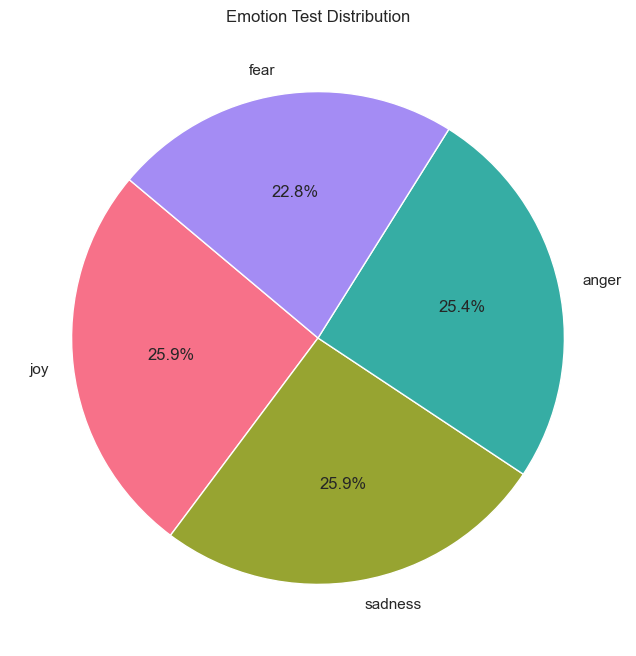

In [14]:
# Count label distributions
label_counts = train_df['emotion'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Test Distribution')
plt.show()

Split data into X, y

In [19]:
# Apply the same filtering to all datasets to ensure consistent labels
val_df = val_df[~val_df['emotion'].str.contains('love')]
val_df = val_df[~val_df['emotion'].str.contains('surprise')]

test_df = test_df[~test_df['emotion'].str.contains('love')]
test_df = test_df[~test_df['emotion'].str.contains('surprise')]

# Update the text and emotion variables after filtering
val_text = val_df['text']
val_emotion = val_df['emotion']

ts_text = test_df['text']
ts_emotion = test_df['emotion']


In [20]:
tr_text = train_df['text']
tr_label = train_df['emotion']

val_text = val_df['text']
val_label = val_df['emotion']

ts_text = test_df['text']
ts_label = test_df['emotion']

 Encoding

In [21]:
encoder = LabelEncoder()
tr_label = encoder.fit_transform(train_emotion)
val_label = encoder.transform(val_emotion)
ts_label = encoder.transform(ts_emotion)

# Text preprocessing

In [22]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train_df) 
                            
sequences = tokenizer.texts_to_sequences(train_df)

tr_x = pad_sequences(sequences, maxlen=50) 
tr_y = to_categorical(tr_label)

sequences = tokenizer.texts_to_sequences(val_text)
val_x = pad_sequences(sequences, maxlen=50)
val_y = to_categorical(val_label)

sequences = tokenizer.texts_to_sequences(ts_text)
ts_x = pad_sequences(sequences, maxlen=50)
ts_y = to_categorical(ts_label)

# 3. Building deep learning model

In [23]:
max_words = 10000
max_len = 50
embedding_dim = 32

3.1 Model architecture

In [ ]:
# Define input layer
input_layer = Input(shape=(max_len,))

# Branch 1 
branch1 = Sequential(name="branch1")
branch1.add(Embedding(max_words, embedding_dim, input_length=max_len))
branch1.add(Conv1D(64, 3, padding='same', activation='relu'))
branch1.add(BatchNormalization())
branch1.add(ReLU())
branch1.add(Dropout(0.5))
branch1.add(GlobalMaxPooling1D())

# Branch 2
branch2 = Sequential(name="branch2")
branch2.add(Embedding(max_words, embedding_dim, input_length=max_len))
branch2.add(Conv1D(64, 3, padding='same', activation='relu'))
branch2.add(BatchNormalization())
branch2.add(ReLU())
branch2.add(Dropout(0.5))
branch2.add(GlobalMaxPooling1D())

# Call the models on input to get their outputs
branch1_output = branch1(input_layer)
branch2_output = branch2(input_layer)

# Now you can concatenate the outputs
concatenated = Concatenate()([branch1_output, branch2_output])

# Continue with the rest of your model
hid_layer = Dense(128, activation='relu')(concatenated)
dropout = Dropout(0.3)(hid_layer)
output_layer = Dense(4, activation='softmax')(dropout)

# Create the model with the input and output layers
model = Model(inputs=input_layer, outputs=output_layer)

NameError: name 'Input' is not defined